# Oscillations

In this notebook, we are going to explore what network structures lead to oscillations, and how they are affected by parameters.

We are going to model examples from the paper by Novák and Tyson [Design principles of biochemical oscillators](https://doi.org/10.1038/nrm2530).

In [1]:
import sys
if '../..' not in sys.path:
    sys.path.append('../..')

from basico import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def plot_x_y(result, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(result["Time"], result["[Y]"], label="Y (protein)")
    axes[0].plot(result["Time"], result["[X]"], label="X (mRNA)")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("concentration")
    axes[0].legend()
    
    axes[1].plot(result["[X]"], result["[Y]"])
    axes[1].set_xlabel("[X]")
    axes[1].set_ylabel("[Y]")
    fig.suptitle(title)
    fig.tight_layout()

## Negative feedback
First, we will make a simple model with two reactions - synthesis and degradation of protein Y. Y inhibits its own synthesis - this is called negative feedback.

In [3]:
new_model(name='Negative feedback')
add_reaction('Synthesis', ' -> Y')
add_reaction('Degradation', 'Y -> ');

In [4]:
add_function("Synthesis_1",
            "k1 * S * Kd^p / (Kd^p + Y^p)",
            mapping = {"k1": "parameter",
                       "S": "parameter",
                       "Y": "product",
                      "Kd": "parameter",
                      "p": "parameter"})
add_function("Degradation_1",
            "k2 * Et * Y / (Km + Y)",
            mapping = {"k2": "parameter",
                       "Et": "parameter",
                       "Y": "substrate",
                      "Km": "parameter"})

<CFunction "Degradation_1">

In [5]:
set_reaction('Synthesis', function='Synthesis_1')
set_reaction('Degradation', function='Degradation_1')

In [6]:
set_reaction_parameters('(Synthesis).k1', value=1)
set_reaction_parameters('(Synthesis).S', value=1)
set_reaction_parameters('(Synthesis).Kd', value=1)
set_reaction_parameters('(Synthesis).p', value=2)

set_reaction_parameters('(Degradation).k2', value=1)
set_reaction_parameters('(Degradation).Et', value=1)
set_reaction_parameters('(Degradation).Km', value=1)

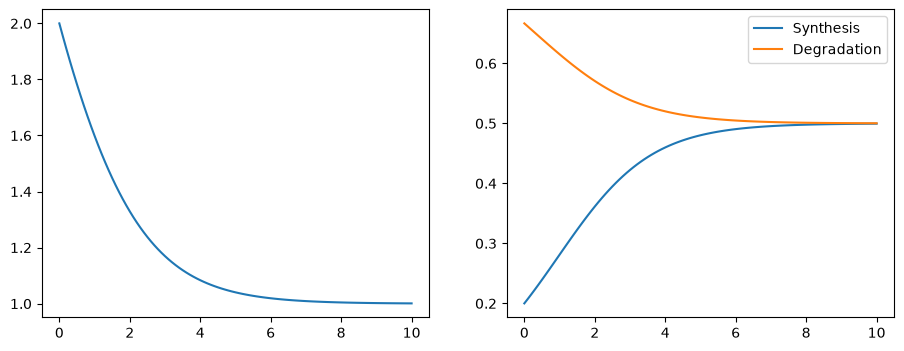

In [8]:
set_species("Y", initial_concentration=2)

result = run_time_course_with_output(["Time", "[Y]", 
                             "(Synthesis).Flux", 
                             "(Degradation).Flux"],
                                    duration=10,
                                    method="deterministic")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

axes[0].plot(result["Time"], result["[Y]"])
axes[1].plot(result["Time"], result["(Synthesis).Flux"], label = "Synthesis")
axes[1].plot(result["Time"], result["(Degradation).Flux"], label = "Degradation")
plt.legend()

We observe that the system reaches a steady state where the rates of synthesis and degradation are equal. This steady state is reached regardless of the initial starting concentration.

## Negative feedback with intermediates

In the next model, we will make it more complicated (and realistic) by adding mRNA. Now the protein Y does not directly inhibit its own synthesis but it inhibits transcription of its own RNA (labelled X).

The syntax here is a little bit different - the components act as **modifiers** in the reactions - that means they affect the reaction rate but are not produced or consumed in the reaction. For example, protein Y inhibits the transcription of its own mRNA, and the mRNA is required for translation as a template.



In [9]:
new_model(name='Negative feedback with intermediates')
add_reaction('Transcription', ' -> X; Y')
add_reaction('Degradation_mRNA', 'X -> ');
add_reaction('Translation', ' -> Y; X')
add_reaction('Degradation_protein', 'Y -> ');

The rate law for **Transcription** is almost the same as before but now Y acts as a modifier. The rate law for **Degradation_protein** is exactly the same.
The rate law for **Degradation_mRNA** is a simple mass action, which is the default - already available in Copasi. The rate of **Translation** is simply proportional to mRNA [X] concentration.

In [10]:
add_function("Transcription",
            "k1 * S * Kd^p / (Kd^p + Y^p)",
            mapping = {"k1": "parameter",
                       "S": "parameter",
                       "Y": "modifier",
                      "Kd": "parameter",
                      "p": "parameter"})

add_function("Translation",
            "ksy * X",
            mapping = {"ksy": "parameter",
                      "X": "modifier"});

In [11]:
set_reaction('Transcription', function='Transcription', mapping={'Y': 'Y'})
set_reaction('Degradation_protein', function='Degradation_1')
set_reaction('Translation', function='Translation', mapping={'X': 'X'})


In [12]:
set_reaction_parameters('(Transcription).k1', value=0.1)
set_reaction_parameters('(Transcription).S', value=4)
set_reaction_parameters('(Transcription).Kd', value=1)
set_reaction_parameters('(Transcription).p', value=2)

set_reaction_parameters('(Translation).ksy', value=1)

set_reaction_parameters('(Degradation_protein).k2', value=1)
set_reaction_parameters('(Degradation_protein).Et', value=1)
set_reaction_parameters('(Degradation_protein).Km', value=0.1)

set_reaction_parameters('(Degradation_mRNA).k1', value=0.1)

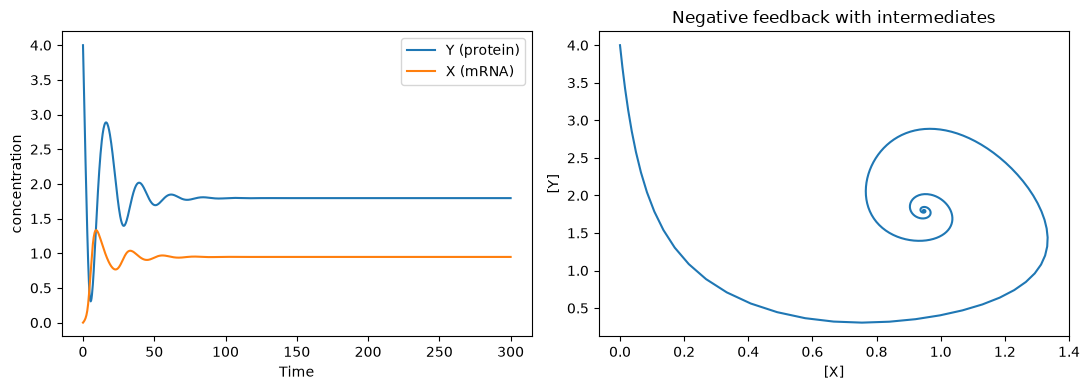

In [13]:
set_species("Y", initial_concentration=4)
set_species("X", initial_concentration=0)

result = run_time_course_with_output(["Time", "[X]", "[Y]"],
                                    duration=300,
                                     step_number=1000,
                                    method="deterministic")

plot_x_y(result, "Negative feedback with intermediates")

A negative feedback loop built from only **two** dynamic species (here, mRNA and protein) generally cannot sustain oscillations no matter how sharp you make the inhibition (try increasing `p` in the cell above, e.g. to 10 or 20 &mdash; the ringing changes, but it still damps out)

## Time delay by positive feedback

Same transcription/translation structure as before, but now protein degradation includes a positive-feedback (ultrasensitive) term. This creates an effective time delay, which can sustain oscillations even with only two dynamic species.

In [14]:
new_model(name='Time delay by positive feedback')
add_reaction('Transcription', ' -> X; Y')
add_reaction('Degradation_mRNA', 'X -> ');
add_reaction('Translation', ' -> Y; X')
add_reaction('Degradation_protein', 'Y -> ');

In [15]:
add_function("Degradation_positive_feedback",
            "kdy * Y + k2 * Et * Y / (Km + Y + Ki * Y^2)",
            mapping = {"kdy": "parameter",
                       "Y": "substrate",
                       "k2": "parameter",
                       "Et": "parameter",
                       "Km": "parameter",
                       "Ki": "parameter"})


<CFunction "Degradation_positive_feedback">

In [16]:
set_reaction('Transcription', function='Transcription', mapping={'Y': 'Y'})
set_reaction('Degradation_protein', function='Degradation_positive_feedback', mapping={'Y': 'Y'})
set_reaction('Translation', function='Translation', mapping={'X': 'X'})


In [17]:
set_reaction_parameters('(Transcription).k1', value=0.05)
set_reaction_parameters('(Transcription).Kd', value=1)

set_reaction_parameters('(Translation).ksy', value=1)

set_reaction_parameters('(Degradation_protein).kdy', value=0.05)
set_reaction_parameters('(Degradation_protein).k2', value=1)
set_reaction_parameters('(Degradation_protein).Et', value=1)
set_reaction_parameters('(Degradation_protein).Km', value=0.1)
set_reaction_parameters('(Degradation_protein).Ki', value=2)

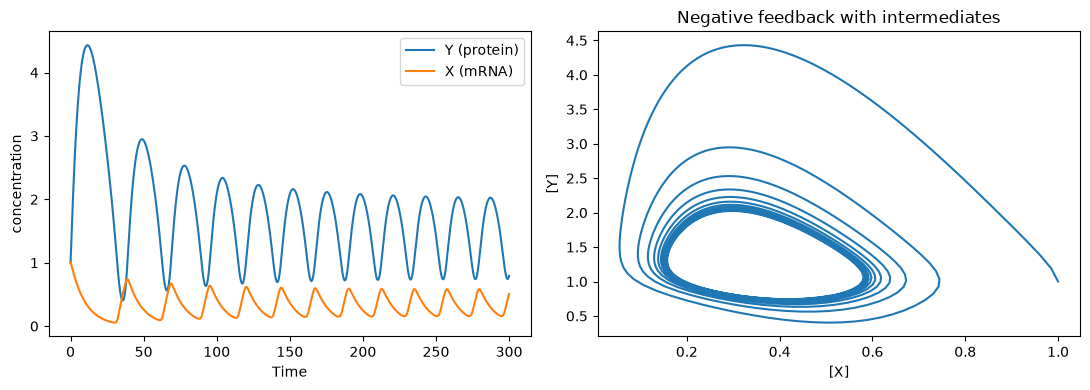

In [28]:
set_reaction_parameters('(Transcription).S', value=3)
set_reaction_parameters('(Transcription).p', value=8)
set_reaction_parameters('(Degradation_mRNA).k1', value=0.1)

set_species("Y", initial_concentration=1)
set_species("X", initial_concentration=1)

result = run_time_course_with_output(["Time", "[X]", "[Y]"],
                                    duration=300,
                                     step_number=1000,
                                    method="deterministic")

plot_x_y(result, "Time delay by positive feedback")

## Realistic model of glycolysis
Now, we will explore oscillations in a more realistic model - a model of glycolysis in S. cerevisiae retrieved from the BioModels database ([BIOMD0000000061](https://www.biomodels.org/BIOMD0000000061)).  

Run a time couirse and plot metabolite concentrations.
Then explore the rate laws and parameters and try to disrupt the oscillations - there might be more than one way to do it. 

Which parameters did you change and why?
Can you identify which elements the system has? (negative feedback, positive feedback, itnermediates, nonlinear rate laws)
How robust is the system - how much did you change the parameter to disrupt the oscillations?

Text(0, 0.5, 'Concentration')

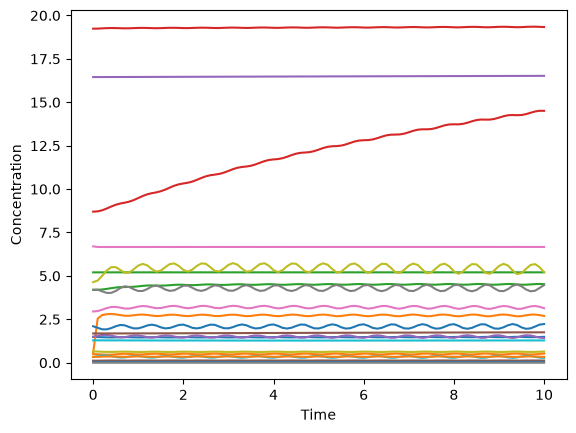

In [38]:
dm = load_model('BIOMD0000000061_url.xml')

result = run_time_course(duration=10, method='deterministic')

fig, ax = plt.subplots()
for col in result.columns:
    ax.plot(result.index, result[col])
ax.set_xlabel('Time')
ax.set_ylabel('Concentration')